In [62]:
# Environment preparation

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, Matern
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats

results_df = pd.DataFrame(columns=['week_number', 'function_number', 'best_output', 'provided_input'])

for X in range(1, 9):
    inputs_path = f"initial_data/function_{X}/initial_inputs.npy"
    outputs_path = f"initial_data/function_{X}/initial_outputs.npy"
    
    globals()[f"f{X}_inputs"] = np.load(inputs_path)
    globals()[f"f{X}_outputs"] = np.load(outputs_path)

    results_df.loc[len(results_df)] = [0, X, np.max(globals()[f"f{X}_outputs"]), globals()[f"f{X}_inputs"][np.argmax(globals()[f"f{X}_outputs"])]]

    print(results_df)

   week_number  function_number   best_output  \
0            0                1  7.710875e-16   

                             provided_input  
0  [0.7310236309563586, 0.7329998764152272]  
   week_number  function_number   best_output  \
0            0                1  7.710875e-16   
1            0                2  6.112052e-01   

                             provided_input  
0  [0.7310236309563586, 0.7329998764152272]  
1  [0.7026365569244406, 0.9265641975455574]  
   week_number  function_number   best_output  \
0            0                1  7.710875e-16   
1            0                2  6.112052e-01   
2            0                3 -3.483531e-02   

                                      provided_input  
0           [0.7310236309563586, 0.7329998764152272]  
1           [0.7026365569244406, 0.9265641975455574]  
2  [0.49258141463713434, 0.6115931882759961, 0.34...  
   week_number  function_number   best_output  \
0            0                1  7.710875e-16   
1       

2d [0.31940389 0.57432921 0.73102363 0.84035342 0.65011406 0.41043714
 0.31269116 0.68341817 0.08250725 0.88388983]
2d [0.76295937 0.8798981  0.73299988 0.26473161 0.68152635 0.1475543
 0.07872278 0.86105746 0.40348751 0.58225397]
y [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
         x1        x2              y
0  0.319404  0.762959   1.322677e-79
1  0.574329  0.879898   1.033078e-46
2  0.731024  0.733000   7.710875e-16
3  0.840353  0.264732  3.341771e-124
4  0.650114  0.681526  -3.606063e-03
5  0.410437  0.147554  -2.159249e-54
6  0.312691  0.078723  -2.089093e-91
7  0.683418  0.861057   2.535001e-40
8  0.082507  0.403488   3.606771e-81
9  0.883890  0.582254   6.229856e-48


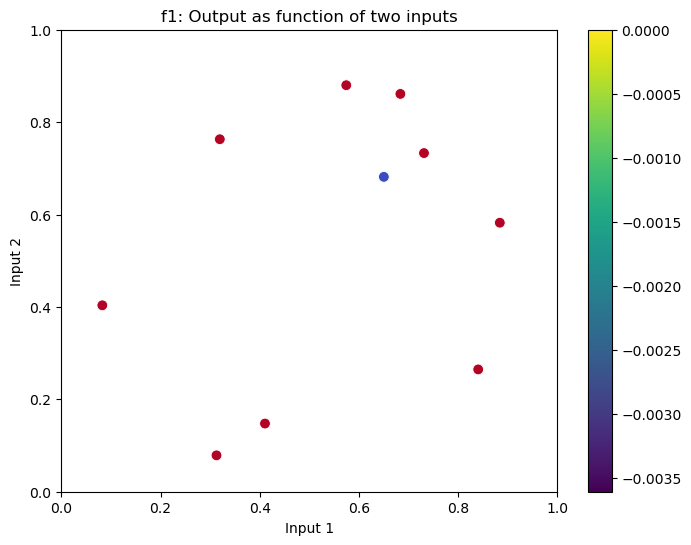

Evaluations: 10
Inputs shape: (10, 2)
Inputs range: [0.883890, 0.983890]
Performance range: [-0.003606, 0.000000]
Current best: 0.000000
Inputs producing current best: [0.73102363 0.73299988]


In [63]:
x1 = f1_inputs[:, 0]
x2 = f1_inputs[:, 1]
y = f1_outputs


print(f"2d {x1}")
print(f"2d {x2}")
print(f"y {y}")

# Put data into a DataFrame
df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "y": y
})

print(df)

# Scatter plot with color encoding the output
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="coolwarm", s=60, legend=False)
plt.title("f1: Output as function of two inputs")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(0, 1)
plt.ylim(0, 1)
norm = plt.Normalize(vmin=y.min(), vmax=y.max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
plt.colorbar(sm, ax=plt.gca())
plt.show()


print(f"Evaluations: {len(f1_inputs)}")
print(f"Inputs shape: {f1_inputs.shape}")
print(f"Inputs range: [{(np.max(f1_inputs) ):.6f}, {(np.max(f1_inputs)+0.1):.6f}]")
print(f"Performance range: [{np.min(f1_outputs):.6f}, {np.max(f1_outputs):.6f}]")
print(f"Current best: {np.max(f1_outputs):.6f}")
print(f"Inputs producing current best: {f1_inputs[np.argmax(f1_outputs)]}")

In [66]:
x1 = f2_inputs[:, 0]
x2 = f2_inputs[:, 1]
y = f2_outputs

print(f"2d {x1}")
print(f"2d {x2}")
print(f"y {y}")

# Put data into a DataFrame
df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "y": y
})

print(df)

# Scatter plot with color encoding the output
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="coolwarm", s=60, legend=False)
plt.title("f1: Output as function of two inputs")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(0, 1)
plt.ylim(0, 1)
norm = plt.Normalize(vmin=y.min(), vmax=y.max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
plt.colorbar(sm, ax=plt.gca())
plt.show()


print(f"Evaluations: {len(f2_inputs)}")
print(f"Inputs shape: {f2_inputs.shape}")
print(f"Inputs range: [{(np.max(f2_inputs)):.6f}, {(np.max(f2_inputs)+0.1):.6f}]")
print(f"Performance range: [{np.min(f2_outputs):.6f}, {np.max(f2_outputs):.6f}]")
print(f"Current best: {np.max(f2_outputs):.6f}")
print(f"Inputs producing current best: {f2_inputs[np.argmax(f2_outputs)]}")

SyntaxError: invalid decimal literal (3272179187.py, line 1)

In [27]:
x1 = f3_inputs[:, 0]
x2 = f3_inputs[:, 1]
x3 = f3_inputs[:, 2]
y = f3_outputs

print(np.max(x1) +0.1)
print(np.max(x2) +0.1)
print(np.max(x3) +0.1)



1.0659948489488087
1.0413598305723257
1.090881866558951


In [31]:
x1 = f4_inputs[:, 0]
x2 = f4_inputs[:, 1]
x3 = f4_inputs[:, 2]
x4 = f4_inputs[:, 3]
y = f4_outputs

print(np.max(x1) +0.1)
print(np.max(x2) +0.1)
print(np.max(x3) +0.1)
print(np.max(x4) +0.1)

1.0856218929694017
1.0195923219593923
1.0391779073552307
1.0994825612275692


In [43]:
x1 = f5_inputs[:, 0]
x2 = f5_inputs[:, 1]
x3 = f5_inputs[:, 2]
x4 = f5_inputs[:, 3]
y = f5_outputs

print(np.max(x1) +0.1)
print(np.max(x2) +0.1)
print(np.max(x3) +0.1)
print(np.max(x4) +0.1)


0.9364779930351232
0.9625403059525095
0.9794841797090803
1.057643898670113


In [44]:
x1 = f6_inputs[:, 0]
x2 = f6_inputs[:, 1]
x3 = f6_inputs[:, 2]
x4 = f6_inputs[:, 3]
x5 = f6_inputs[:, 4]
y = f6_outputs

print(np.max(x1) +0.1)
print(np.max(x2) +0.1)
print(np.max(x3) +0.1)
print(np.max(x4) +0.1)
print(np.max(x5) +0.1)

1.057739668883361
1.0318712161635006
1.0788057635601997
1.0616555869902995
0.992819191058788


In [40]:
x1 = f7_inputs[:, 0]
x2 = f7_inputs[:, 1]
x3 = f7_inputs[:, 2]
x4 = f7_inputs[:, 3]
x5 = f7_inputs[:, 4]
x6 = f7_inputs[:, 5]
y = f7_outputs

print(np.max(x1) +0.1)
print(np.max(x2) +0.1)
print(np.max(x3) +0.1)
print(np.max(x4) +0.1)
print(np.max(x5) +0.1)
print(np.max(x6) +0.1)

1.042450839379723
1.0246939036961067
1.0245705141349382
1.0610171372277224
1.0986546964586872
1.0510139152470552


In [41]:
x1 = f8_inputs[:, 0]
x2 = f8_inputs[:, 1]
x3 = f8_inputs[:, 2]
x4 = f8_inputs[:, 3]
x5 = f8_inputs[:, 4]
x6 = f8_inputs[:, 5]
x7 = f8_inputs[:, 6]
y = f8_outputs

print(np.max(x1) +0.1)
print(np.max(x2) +0.1)
print(np.max(x3) +0.1)
print(np.max(x4) +0.1)
print(np.max(x5) +0.1)
print(np.max(x6) +0.1)
print(np.max(x7) +0.1)

1.08594538963311
1.073979787491971
1.098885496855836
1.002985774748292
1.086901999632929
1.0902438143772586
1.092914494924961
